# Charged Black Holes in Entangled Relativity
## Arnaud Crepinge - M2 Internship

### Massive Particles Dynamics Analysis

### Normalizing wrt Mass

In [1]:
# Import libraries

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from scipy.integrate import quad
from matplotlib.colors import LogNorm

# Font for plotting

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

## 1 - Definitions

In [2]:
# Horizons in GR

def rpm_GR(M, Q):
    sqrt = sp.sqrt if isinstance(M, sp.Basic) else np.sqrt
    disc = sqrt(M**2 - Q**2)
    return M + disc, M - disc

# Horizons in ER

def rpm_ER(M, Q):
    disc = np.sqrt(M**2 - (11/12) * Q**2)
    return M + disc, (13/11) * (M - disc)

def rpm_ER_sym(M, Q):
    disc = sp.sqrt(M**2 - sp.Rational(11, 12) * Q**2)
    return M + disc, sp.Rational(13, 11) * (M - disc)

# 3rd Kepler's law in GR (for circular orbit)

def kep_GR(r, M, Q):
    return (M / r**3) - (Q**2 / r**4)

# 3rd Kepler's law in ER (for circular orbit)

def kep_ER(r, M, Q):
    rm = rpm_ER(M, Q)[-1]
    GR = kep_GR(r, M, Q)
    num = (1 - rm/r)**(9/13)
    denom = 1 - (12/13) * (rm/r)
    return GR * num / denom

# Areal radius ρ as a function of coordinate radius r
# In GR : g_φφ = r² sin²θ  →  ρ = r
# In ER : g_φφ = r²(1 - rm/r)^(2/13) sin²θ  →  ρ = r(1 - rm/r)^(1/13)

def rho_GR(r, M, Q): 
    return r
    
def rho_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    return r * (1 - rm / r) ** (1 / 13)

def r_coord(rho, M, Q):
    rp, rm = rpm_ER(M, Q)
    if np.isclose(Q, 0):
        return rho
    if np.isclose(rho, 0):
        return rm
    return brentq(lambda x: rho_ER(x, M, Q) - rho, rm, rho + 2*rp)

# Derivative of rho wrt r

def drho_dr_GR(r, M, Q):
    return 1

def drho_dr_ER(r, M, Q):
    _, rm = rpm_ER(M, Q)
    u = (1 - rm / r)**(-12/13)
    return u * (1 - (12 * rm) / (13 * r))

### Computing the Christoffel Symbols

In [3]:
# Coordinates & Parameters

t, r, th, ph = sp.symbols('t r theta phi', real=True, positive=True)
M, Q         = sp.symbols('M Q', real=True, positive=True)

coords  = [t, r, th, ph]
params  = [M, Q]
all_sym = coords + params

# Metric for GR -> Reissner-Nordström

rp_GR, rm_GR = rpm_GR(M,Q)
f = (1 - rm_GR/r) * (1 - rp_GR/r)

g_GR = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2]
])

# Metric for ER

rp_ER, rm_ER = rpm_ER_sym(M,Q)
f = (1 - rp_ER/r) * (1 - rm_ER/r)**sp.Rational(11, 13)
f2 = (1 - rm_ER/r)**sp.Rational(2, 13)

g_ER = sp.Matrix([
    [-f, 0, 0, 0],
    [0, 1/f, 0, 0],
    [0, 0, r**2 * f2, 0],
    [0, 0, 0, r**2 * sp.sin(th)**2 * f2]
])

# Computing Christoffel Symbols

def compute_christoffel_sym(g, coords):
    n   = len(coords)
    g_inv = g.inv()
    
    # ∂_σ g_μν  — precomputed once
    dg = [[[sp.diff(g[m, n_], coords[s]) for s in range(n)]
            for n_ in range(n)]
           for m in range(n)]
    
    G = [[[None]*n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for al in range(n):
            for be in range(al, n):          # exploit symmetry Γ^μ_αβ = Γ^μ_βα
                s = sum(
                    g_inv[mu, nu] * (dg[nu][be][al] + dg[nu][al][be] - dg[al][be][nu])
                    for nu in range(n)
                )
                expr = sp.radsimp(sp.powsimp(s / 2, force=True))
                G[mu][al][be] = expr
                G[mu][be][al] = expr         # symmetry copy
    return G

print("Computing Christoffel symbols for GR... ", end="", flush=True)
G_GR = compute_christoffel_sym(g_GR, coords)
print("Computing Christoffel symbols for ER... ", end="", flush=True)
G_ER = compute_christoffel_sym(g_ER, coords)
print("done")

Computing Christoffel symbols for GR... Computing Christoffel symbols for ER... done


In [4]:
# Lambdify to obtain functions

G_num_GR = sp.lambdify(all_sym, sp.Array(G_GR), "numpy")
G_num_ER = sp.lambdify(all_sym, sp.Array(G_ER), "numpy")

g_num_GR = sp.lambdify(all_sym, g_GR, "numpy")

g_num_ER = sp.lambdify(all_sym, g_ER, "numpy")

### Solving Equations

In [5]:
def geodesic_rhs(lam, state, G_num, M_val, Q_val): 
    x = state[:4]
    k = state[4:]
    args = (*x, M_val, Q_val)

    G = np.array(G_num(*args), dtype=float)  # single call, 64x fewer Python-level dispatches

    # Faster — pure NumPy
    dk = -np.einsum('mab,a,b->m', G, k, k)
    return np.concatenate([k, dk])


def fix_kt(x0, kr, kth, kph, g_num, M_val, Q_val):
    args  = (*x0, M_val, Q_val)
    g_mat = np.array(g_num(*args), dtype=float)
    A = -g_mat[0, 0]
    B = g_mat[1,1]*kr**2 + g_mat[2,2]*kth**2 + g_mat[3,3]*kph**2 + 1
    return np.sqrt(B / A)

# Check normalization

def check_normalization(sol, g_num, M_val, Q_val, target=0.0):
    norms = np.zeros(sol.y.shape[1])
    for i in range(sol.y.shape[1]):
        x = sol.y[:4, i]
        k = sol.y[4:, i]
        g = np.array(g_num(*x, M_val, Q_val), dtype=float)
        norms[i] = np.einsum('mn,m,n->', g, k, k)
    return norms - target   # deviation from expected value

## 2 - Plotting Trajectories

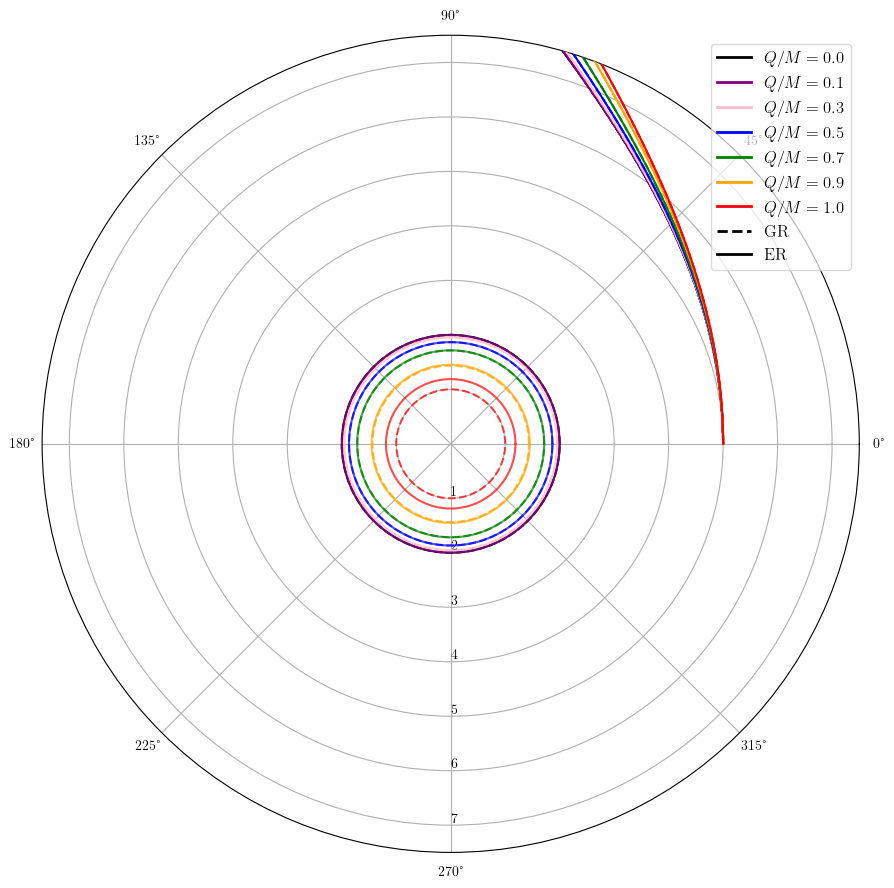

In [6]:
### ── Parameters ────────────────────────────────────────────────────────────────
# Format: (M, Q, color, label)
cases = [
    (1.0, 0.0, 'black',  r'$Q/M = 0.0$'),
    (1.0, 0.1, 'purple', r'$Q/M = 0.1$'),
    (1.0, 0.3, 'pink',   r'$Q/M = 0.3$'),
    (1.0, 0.5, 'blue',   r'$Q/M = 0.5$'),
    (1.0, 0.7, 'green',   r'$Q/M = 0.7$'),
    (1.0, 0.9, 'orange', r'$Q/M = 0.9$'),
    (1.0, 1.0, 'red',    r'$Q/M = 1.0$')
]

rho_init = 5.0 # Must be strictly greater than 2 (Schwarzschild horizon)

# Areal radius Initial Conditions
krho_init   = 0   # Radial velocity
kph_init  = 1   # Angular velocity

# ── Absorption event factory ───────────────────────────────────────────────────
def make_absorption_event(rp_val):
    def absorbed(lam, s):
        return s[1] - rp_val * 1.005  # Stops just outside the coordinate horizon
    absorbed.terminal  = True
    absorbed.direction = -1
    return absorbed

# ── Solver ────────────────────────────────────────────────────────────────────
def solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0, lam_max=20, n_pts=20000):
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    kt = fix_kt(x0, kr, 0.0, kph, g_num, M_val, Q_val)
    k0 = np.array([kt, kr, 0.0, kph])

    rp, _ = rpm_func(M_val, Q_val)
    event = make_absorption_event(float(rp))

    sol = solve_ivp(
        fun=lambda lam, s: geodesic_rhs(lam, s, G_num, M_val, Q_val),
        t_span=(0, lam_max),
        y0=np.concatenate([x0, k0]),
        t_eval=np.linspace(0, lam_max, n_pts),
        method="DOP853",
        rtol=1e-10, atol=1e-12,
        events=event,
    )
    return sol

# ── Plot Setup ────────────────────────────────────────────────────────────────
theories = [
    ("GR", G_num_GR, g_num_GR, rpm_GR, rho_GR, drho_dr_GR, '--'),
    ("ER", G_num_ER, g_num_ER, rpm_ER, rho_ER, drho_dr_ER, '-'),
]

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

# ── Integrate and Plot ────────────────────────────────────────────────────────
for M_val, Q_val, color, label in cases:
    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # 1. Calculate the physical outer horizon (rho_+) for this specific case
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # 2. Dynamically define the injection point
        rho0_local = rho_init * M_val

        # 3. Map that case-specific areal radius to the required coordinate r0
        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        kr = krho_init / drho_dr_func(r0_init, M_val, Q_val)
        kph = kph_init

        # 4. Solve the geodesic equations in terms of coordinate r
        sol = solve_geodesic(G_num, g_num, rpm_func, M_val, Q_val, kr, kph, r0=r0_init)

        # 5. Map coordinate r back to physical rho, then scale by M
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / M_val
        phi_trajectory = sol.y[3]

        # (draws a thin horizon ring for each case × theory, in matching color)
        ax.plot(theta_circle, np.full_like(theta_circle, rho_plus / M_val),
                color=color, lw=1.5, linestyle=linestyle, alpha=0.7, zorder=5)

        # 6. Plot the mass-scaled physical trajectory
        ax.plot(phi_trajectory, rho_scaled,
                color=color, lw=1.5, linestyle=linestyle, zorder=4)

        if sol.status == 1:
            ax.plot(phi_trajectory[-1], rho_scaled[-1],
                    'x', color=color, ms=6, zorder=6)

# ── Custom Legends ────────────────────────────────────────────────────────────
color_handles = [Line2D([0], [0], color=c, lw=2, label=lbl) for _, _, c, lbl in cases]
style_handles = [
    Line2D([0], [0], color='black', lw=2, linestyle='--', label=r'GR'),
    Line2D([0], [0], color='black', lw=2, linestyle='-', label=r'ER')
]
handles = color_handles + style_handles
ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

# Set radial limits to focus on the action near the photon sphere
ax.set_rmax(1.5*rho_init)

plt.tight_layout()
plt.savefig("images/Massive_Mass.png", dpi=150, bbox_inches='tight')

Skipped GR, Q/M=0.00: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.00: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=0.10: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.10: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=0.30: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.30: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=0.50: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.50: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=0.70: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.70: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=0.90: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=0.90: b/M=4.500 not allowed at rho0/M=5.0
Skipped GR, Q/M=1.00: b/M=4.500 not allowed at rho0/M=5.0
Skipped ER, Q/M=1.00: b/M=4.500 not allowed at rho0/M=5.0


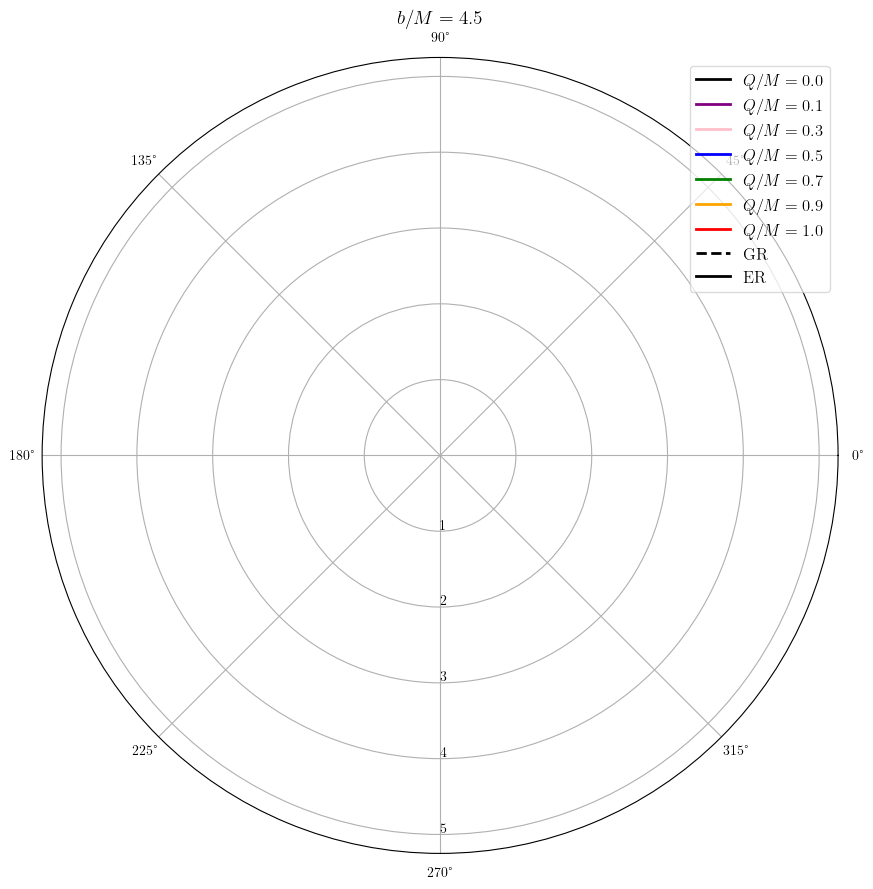

In [7]:
# ── Trajectories at fixed impact parameter b ─────────────────────────────────

b_over_M = 4.5      # Choose common impact parameter b/M
E_val = 1.0         # Only fixes affine parametrization
radial_sign = -1    # -1 inward, +1 outward
angular_sign = +1   # +1 counterclockwise, -1 clockwise

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(9, 9))
ax.set_rlabel_position(270)

theta_circle = np.linspace(0, 2*np.pi, 500)

def initial_k_from_b(g_num, M_val, Q_val, r0, b, E=1.0, radial_sign=-1, angular_sign=+1):
    """
    Build initial particle 4-velocity from fixed impact parameter b = |L|/E.

    Metric convention:
        ds² = -A dt² + B dr² + C dφ²
    Equatorial plane:
        θ = π/2
    """
    x0 = np.array([0.0, r0, np.pi/2, 0.0])
    g = np.array(g_num(*x0, M_val, Q_val), dtype=float)

    A = -g[0, 0]
    B =  g[1, 1]
    C =  g[3, 3]

    L = angular_sign * b * E

    kt  = E / A
    kph = L / C

    radicand = (E**2 / A - L**2 / C - 1.0) / B

    if radicand < 0:
        return None

    kr = radial_sign * np.sqrt(radicand)

    return kt, kr, kph


for M_val, Q_val, color, label in cases:

    b_val = b_over_M * M_val

    for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:

        # Horizon
        rp_coord, _ = rpm_func(M_val, Q_val)
        rho_plus = rho_func(rp_coord, M_val, Q_val)

        # Same initial areal radius rho0 for both theories
        rho0_local = rho_init * M_val

        if theory_name == "GR":
            r0_init = rho0_local
        else:
            r0_init = r_coord(rho0_local, M_val, Q_val)

        # Initial k from common impact parameter b
        k_init = initial_k_from_b(
            g_num,
            M_val,
            Q_val,
            r0_init,
            b=b_val,
            E=E_val,
            radial_sign=radial_sign,
            angular_sign=angular_sign
        )

        if k_init is None:
            print(f"Skipped {theory_name}, Q/M={Q_val/M_val:.2f}: b/M={b_over_M:.3f} not allowed at rho0/M={rho_init}")
            continue

        kt, kr, kph = k_init

        # Optional diagnostic: corresponding areal radial component
        krho = drho_dr_func(r0_init, M_val, Q_val) * kr

        # Solve using coordinate components
        sol = solve_geodesic(
            G_num,
            g_num,
            rpm_func,
            M_val,
            Q_val,
            kr=kr,
            kph=kph,
            r0=r0_init
        )

        # Convert trajectory to areal radius
        rho_trajectory = rho_func(sol.y[1], M_val, Q_val)
        rho_scaled = rho_trajectory / M_val
        phi_trajectory = sol.y[3]

        # Horizon ring
        ax.plot(
            theta_circle,
            np.full_like(theta_circle, rho_plus / M_val),
            color=color,
            lw=1.5,
            linestyle=linestyle,
            alpha=0.7,
            zorder=5
        )

        # Trajectory
        ax.plot(
            phi_trajectory,
            rho_scaled,
            color=color,
            lw=1.5,
            linestyle=linestyle,
            zorder=4
        )

        if sol.status == 1:
            ax.plot(
                phi_trajectory[-1],
                rho_scaled[-1],
                'x',
                color=color,
                ms=6,
                zorder=6
            )

# ── Legends ──────────────────────────────────────────────────────────────────

ax.legend(handles=handles, loc="upper right", fontsize=12, framealpha=0.7)

ax.set_title(rf'$b/M = {b_over_M}$', fontsize=14)
ax.set_rlim(0, rho_init * 1.05)

plt.tight_layout()
#plt.savefig(f"images/Massive_FixedImpact_b{b_over_M:.2f}.png", dpi=150, bbox_inches='tight')

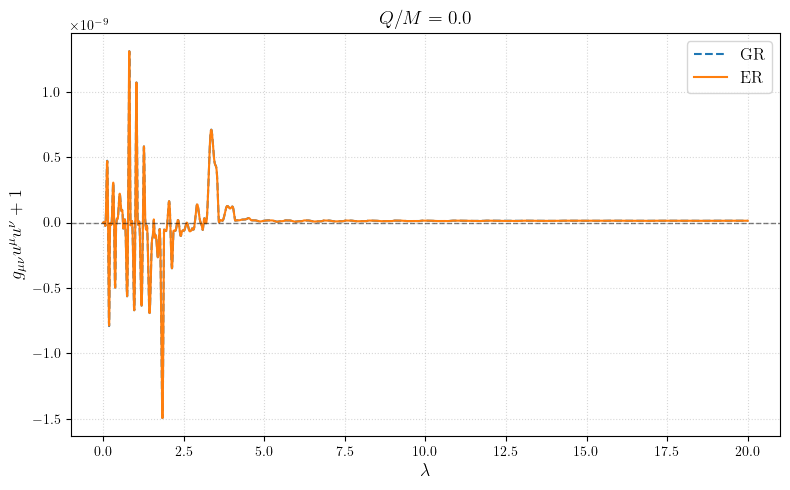

In [8]:
# ── Parameters ────────────────────────────────────────────────────────────────
Q_norm = 0.

# Setup a single panel plot
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization ─────────────────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate the matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init # M = 1
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    kr = krho_init / drho_dr_func(r0_init, 1, Q_norm)
    kph = kph_init

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Calculate the actual constraint deviation (should theoretically be 0.0)
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=-1.0)

    # 4. Plot tracking over the affine parameter lambda
    ax.plot(sol.t, residuals, linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\lambda$", fontsize=13)
ax.set_ylabel(r"$g_{\mu\nu}u^\mu u^\nu + 1$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Draw an explicit ideal baseline at 0
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)

ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()

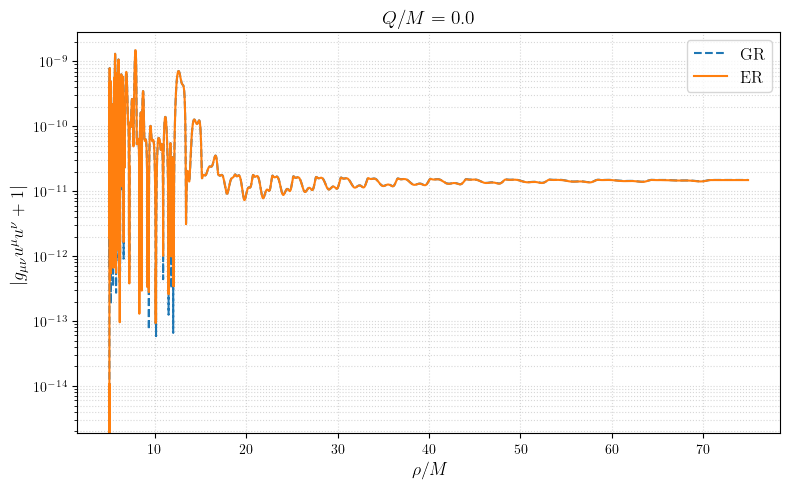

In [9]:
# ── Parameters ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# ── Integrate and Track Normalization vs Radius ───────────────────────────────
for theory_name, G_num, g_num, rpm_func, rho_func, drho_dr_func, linestyle in theories:
    
    # 1. Dynamically calculate matching initial coordinate radius r0
    rp_coord, _ = rpm_func(1.0, Q_norm)
    rho_plus = rho_func(rp_coord, 1.0, Q_norm)
    rho0_local = rho_init # M = 1
    
    if theory_name == "GR":
        r0_init = rho0_local
    else:
        r0_init = r_coord(rho0_local, 1.0, Q_norm)

    kr = krho_init / drho_dr_func(r0_init, 1, Q_norm)
    kph = kph_init

    # 2. Solve the geodesic system
    sol = solve_geodesic(G_num, g_num, rpm_func, 1.0, Q_norm, kr, kph, r0=r0_init)
    
    # 3. Extract physical areal radius profile and constraint residuals
    rho_trajectory = rho_func(sol.y[1], 1.0, Q_norm) 
    residuals = check_normalization(sol, g_num, 1.0, Q_norm, target=-1.0)

    # 4. Plot absolute error vs Real Physical Distance on a Log Scale
    ax.plot(rho_trajectory, np.abs(residuals), linestyle=linestyle, lw=1.5, label=theory_name)

# ── Plot Styling ──────────────────────────────────────────────────────────────
ax.set_xlabel(r"$\rho / M$", fontsize=13)
ax.set_ylabel(r"$|g_{\mu\nu}u^\mu u^\nu + 1|$", fontsize=13)
ax.set_title(f"$Q/M = {Q_norm}$", fontsize=14)

# Use log scale to clearly separate exponential growth from flat freezing
ax.set_yscale('log') 
ax.grid(True, which='both', linestyle=':', alpha=0.5)
ax.legend(fontsize=12)

plt.tight_layout()

## 3 - 3rd Kepler's Law

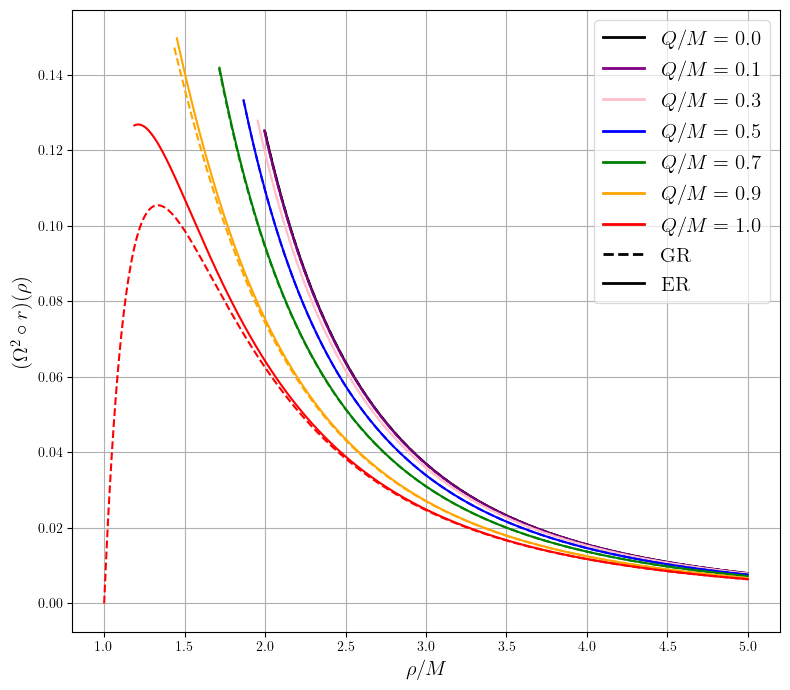

In [10]:
plt.figure(figsize=(8,7))

for M_val, Q_val, color, label in cases:
    rmin_GR = rpm_GR(M_val, Q_val)[0]
    rmin_ER = rpm_ER(M_val, Q_val)[0]

    rho_min_GR = rmin_GR
    rho_min_ER = rho_ER(rmin_ER, M_val, Q_val)

    rhoGR = np.linspace(rho_min_GR, 5 * M_val, 1000)
    rhoER = np.linspace(rho_min_ER, 5 * M_val, 1000)

    rGR = rhoGR
    rER = np.array([r_coord(rho, M_val, Q_val) for rho in rhoER])

    KEP_GR = np.array([kep_GR(r, M_val, Q_val) for r in rGR])
    KEP_ER = np.array([kep_ER(r, M_val, Q_val) for r in rER])

    plt.plot(rhoGR, KEP_GR, label=label, color=color, linestyle='--')
    plt.plot(rhoER, KEP_ER, color=color, linestyle='-')

plt.grid()
plt.legend(handles=handles,
          loc="upper right", fontsize=15, framealpha=0.7)
plt.xlabel(r'$\rho/M$', fontsize=15)
plt.ylabel(r'$(\Omega^2 \circ r)(\rho)$', fontsize=15)

plt.tight_layout()

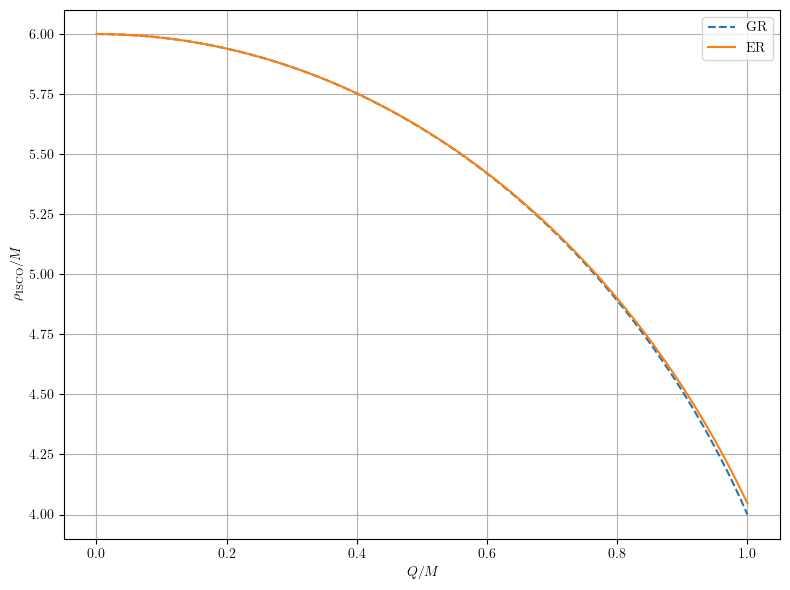

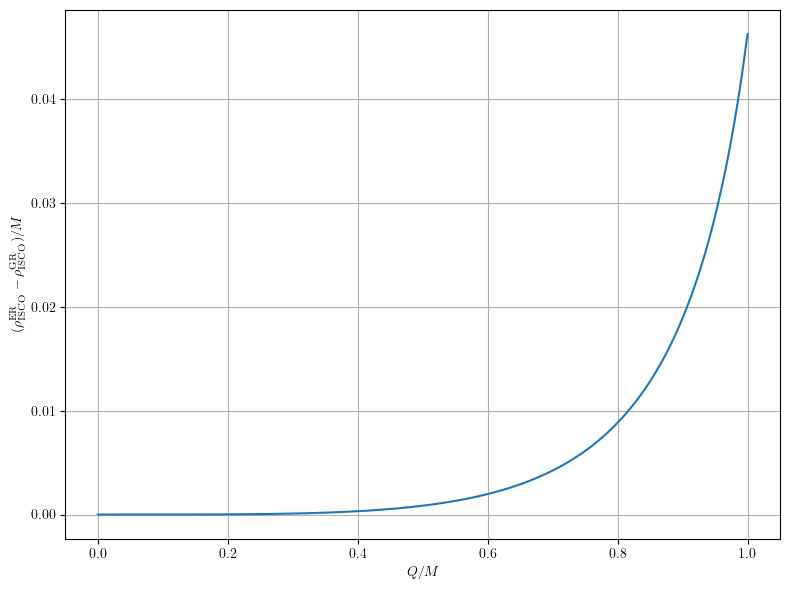

In [11]:
def _real_roots(coeffs, tol=1e-8):
    roots = np.roots(np.asarray(coeffs, dtype=float))
    return np.array(sorted(
        z.real for z in roots if abs(z.imag) < tol
    ))


def isco_GR(M, Q):
    q = Q / M

    if abs(q) > 1:
        raise ValueError("RN black hole requires |Q/M| <= 1.")

    x_plus = 1 + np.sqrt(1 - q**2)
    x_ph = 0.5 * (3 + np.sqrt(9 - 8*q**2))

    # x = r/M
    roots = _real_roots([
        1,
        -6,
        9*q**2,
        -4*q**4
    ])

    valid = roots[roots > max(x_plus, x_ph) * (1 + 1e-10)]
    if len(valid) == 0:
        raise RuntimeError("No physical GR ISCO root found.")

    x_isco = valid[-1]

    omega_M = np.sqrt(
        1 / x_isco**3 - q**2 / x_isco**4
    )

    return {
        "r_over_M": x_isco,
        "rho_over_M": x_isco,
        "M_Omega": omega_M
    }


def isco_ER(M, Q):
    q = Q / M

    disc = 1 - (11 / 12) * q**2
    if disc < 0:
        raise ValueError("ER horizon parameters are not real.")

    # Dimensionless r_+/M and r_-/M
    d = np.sqrt(disc)
    a = 1 + d
    b = (13 / 11) * (1 - d)

    coeffs = [
        2197*a + 1859*b,

        -(6591*a**2 + 13351*a*b + 6578*b**2),

        24336*a**2*b + 25740*a*b**2 + 4620*b**3,

        -(31668*a**2*b**2 + 14388*a*b**3),

        13824*a**2*b**3
    ]

    roots = _real_roots(coeffs)

    # Outer photon sphere
    ph_roots = _real_roots([
        26,
        -(39*a + 35*b),
        48*a*b
    ])
    x_ph = ph_roots[-1]

    valid = roots[
        roots > max(a, b, x_ph) * (1 + 1e-10)
    ]

    if len(valid) == 0:
        raise RuntimeError("No physical ER ISCO root found.")

    x_isco = valid[-1]

    rho_over_M = (
        x_isco * (1 - b / x_isco)**(1 / 13)
    )

    omega2_M2 = (
        (1 / x_isco**3 - q**2 / x_isco**4)
        * (1 - b / x_isco)**(9 / 13)
        / (1 - 12*b / (13*x_isco))
    )

    return {
        "r_over_M": x_isco,
        "rho_over_M": rho_over_M,
        "M_Omega": np.sqrt(omega2_M2)
    }


# Comparison plot
q_values = np.linspace(0, 1, 201)

rho_isco_GR = np.array([
    isco_GR(1.0, q)["rho_over_M"] for q in q_values
])

rho_isco_ER = np.array([
    isco_ER(1.0, q)["rho_over_M"] for q in q_values
])

plt.figure(figsize=(8, 6))
plt.plot(q_values, rho_isco_GR, "--", label="GR")
plt.plot(q_values, rho_isco_ER, "-", label="ER")
plt.xlabel(r"$Q/M$")
plt.ylabel(r"$\rho_{\rm ISCO}/M$")
plt.grid()
plt.legend()
plt.tight_layout()

plt.figure(figsize=(8, 6))
plt.plot(q_values, rho_isco_ER - rho_isco_GR)
plt.xlabel(r"$Q/M$")
plt.ylabel(
    r"$(\rho_{\rm ISCO}^{\rm ER}"
    r"-\rho_{\rm ISCO}^{\rm GR})/M$"
)
plt.grid()
plt.tight_layout()

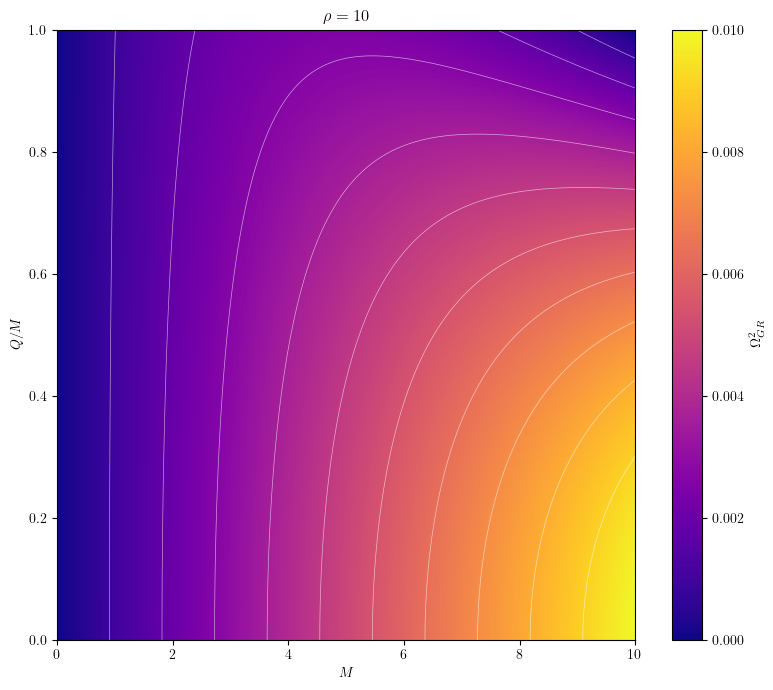

In [12]:
# Heat map GR

rho_fixed = 10
M_max = 10
n_grid = 500

M_vals  = np.linspace(0, M_max, n_grid)
Q_vals  = np.linspace(0,1, n_grid)
M_grid, Q_grid = np.meshgrid(M_vals, Q_vals)

Z_GR = kep_GR(rho_fixed, M_grid, Q_grid*M_grid)

vmin           = np.min(Z_GR)
vmax           = np.max(Z_GR)
contour_levels = np.linspace(vmin, vmax, 12)

plt.figure(figsize=(8,7))

im = plt.imshow(Z_GR, extent=[0, M_max, 0, 1], origin='lower', aspect='auto',
            cmap='plasma', vmin=vmin, vmax=vmax)
plt.contour(M_vals, Q_vals, Z_GR, levels=contour_levels,
            colors='white', linewidths=0.5, alpha=0.6)
plt.colorbar(im, label=r'$\Omega^2_{GR}$')

plt.xlabel(r'$M$')
plt.ylabel(r'$Q/M$')
plt.title(rf"$\rho = {rho_fixed}$")

plt.tight_layout()